# Projet Deep Learning – EMSI Casablanca (2025–2026)
## Partie I : MLP et ingénierie PyTorch
**Dataset :** Breast Cancer Wisconsin


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# 1. Concepts fondamentaux en PyTorch

---

## 1.1 Le Module (`nn.Module`)
Abstraction centrale et brique fondamentale en PyTorch. Qu'il s'agisse d'une couche unique, d'un bloc de calcul ou d'un réseau complet, un module encapsule une transformation des données et s'intègre automatiquement au calcul des gradients.

## 1.2 La Propagation Avant (*Forward*)
Processus de transmission des données à travers le réseau. Le module reçoit une entrée et calcule une sortie via la méthode `forward`. Lors de cette phase, le réseau transforme progressivement l'entrée en représentations cachées, puis en prédictions finales, en combinant des opérations linéaires et des fonctions d'activation (comme ReLU).

## 1.3 La Rétropropagation (*Backward*)
Phase de calcul des dérivées après l'évaluation de la perte (*loss*). L'appel à `loss.backward()` déclenche la rétropropagation, permettant de calculer automatiquement le gradient de la perte par rapport à chaque paramètre apprenable. Les gradients ainsi obtenus sont mis à disposition de l'optimiseur pour ajuster les poids.

## 1.4 Les Paramètres
Variables apprenables du modèle, correspondant principalement aux poids (*weights*) et aux biais (*bias*) des couches linéaires ou convolutives. L'inspection globale de leur structure et de leurs dimensions s'effectue via l'itération fournie par `named_parameters()`.

## 1.5 Le Gradient
Mesure de la sensibilité de la fonction de perte par rapport à un paramètre. Initialement égal à `None`, le gradient n'apparaît et ne devient disponible qu'après la propagation avant, le calcul de la perte et l'exécution de `loss.backward()`.

## 1.6 Le `state_dict`
Dictionnaire Python qui associe à chaque nom de paramètre son tenseur correspondant. Il constitue le format standard de sauvegarde. Ce dictionnaire ne contenant pas le code Python de l'architecture, il est nécessaire de recréer la structure du réseau avant d'y recharger les paramètres.

## 1.7 Le Device
Emplacement matériel et mémoire d'exécution, à savoir le processeur (CPU) ou la carte graphique (GPU). Le GPU accélère fortement les opérations matricielles massives. Une règle absolue impose que le modèle et les données soient situés sur le même device pour que les opérations soient possibles.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Device utilisé : {device}")

[INFO] Device utilisé : cpu


## 2. Préparation des données

- **Nettoyage** : vérification de l'absence de valeurs manquantes.
- **Encodage** : toutes les variables sont déjà numériques continues (pas d'encodage catégoriel nécessaire ici).
- **Normalisation** : `StandardScaler`, **fit uniquement sur train** pour éviter toute fuite d'information (data leakage).
- **Split** : 60% train / 20% validation / 20% test, **stratifié** pour préserver la proportion des classes.


In [ ]:
def prepare_data():
    data = load_breast_cancer()
    X, y = data.data, data.target  # y: 0=malin, 1=bénin
    feature_names = data.feature_names

    print(f"[INFO] Shape X : {X.shape}, classes : {np.unique(y)}")
    print(f"[INFO] Distribution des classes : {np.bincount(y)}")
    assert not np.isnan(X).any(), "Valeurs manquantes détectées !"

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.4, random_state=SEED, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    to_tensor = lambda arr, dtype: torch.tensor(arr, dtype=dtype)
    X_train_t = to_tensor(X_train, torch.float32)
    X_val_t = to_tensor(X_val, torch.float32)
    X_test_t = to_tensor(X_test, torch.float32)
    y_train_t = to_tensor(y_train, torch.float32).unsqueeze(1)
    y_val_t = to_tensor(y_val, torch.float32).unsqueeze(1)
    y_test_t = to_tensor(y_test, torch.float32).unsqueeze(1)

    train_ds = TensorDataset(X_train_t, y_train_t)
    val_ds = TensorDataset(X_val_t, y_val_t)
    test_ds = TensorDataset(X_test_t, y_test_t)

    return train_ds, val_ds, test_ds, X.shape[1], feature_names

train_ds, val_ds, test_ds, input_dim, feature_names = prepare_data()
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)
print(f"[INFO] input_dim = {input_dim}")

[INFO] Shape X : (569, 30), classes : [0 1]
[INFO] Distribution des classes : [212 357]
[INFO] input_dim = 30


## 3. Deux implémentations du MLP

- **`nn.Sequential`** : déclaratif, rapide à écrire, mais peu flexible (pas de branches, pas de logique conditionnelle dans le forward).
- **Classe personnalisée** (héritant de `nn.Module`) : on écrit explicitement le `forward`, ce qui permet d'ajouter facilement des skip-connections, sorties multiples, etc.


In [4]:
def build_mlp_sequential(input_dim, hidden_dims=(32, 16), dropout=0.0):
    layers = []
    dims = [input_dim] + list(hidden_dims)
    for i in range(len(dims) - 1):
        layers.append(nn.Linear(dims[i], dims[i + 1]))
        layers.append(nn.ReLU())
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
    layers.append(nn.Linear(dims[-1], 1))  # 1 logit (classification binaire)
    return nn.Sequential(*layers)


class MLPCustom(nn.Module):
    def __init__(self, input_dim, hidden_dims=(32, 16), dropout=0.0):
        super().__init__()
        dims = [input_dim] + list(hidden_dims)
        self.hidden_layers = nn.ModuleList(
            [nn.Linear(dims[i], dims[i + 1]) for i in range(len(dims) - 1)]
        )
        self.output_layer = nn.Linear(dims[-1], 1)
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout) if dropout > 0 else None

    def forward(self, x):
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
            if self.dropout is not None:
                x = self.dropout(x)
        return self.output_layer(x)

## 4. Inspection des paramètres : `named_parameters()` et `state_dict()`

In [5]:
def inspect_parameters(model, name="Modèle"):
    print(f"\n--- Inspection des paramètres : {name} ---")
    total_params = 0
    for pname, param in model.named_parameters():
        n = param.numel()
        total_params += n
        print(f"  {pname:30s} shape={tuple(param.shape)}  requires_grad={param.requires_grad}  n_params={n}")
    print(f"  TOTAL paramètres entraînables : {total_params}")
    print(f"  Clés du state_dict : {list(model.state_dict().keys())}")
    return total_params

model_seq = build_mlp_sequential(input_dim, hidden_dims=(32, 16))
model_custom = MLPCustom(input_dim, hidden_dims=(32, 16))

inspect_parameters(model_seq, "MLP (nn.Sequential)")
inspect_parameters(model_custom, "MLP (classe personnalisée)")


--- Inspection des paramètres : MLP (nn.Sequential) ---
  0.weight                       shape=(32, 30)  requires_grad=True  n_params=960
  0.bias                         shape=(32,)  requires_grad=True  n_params=32
  2.weight                       shape=(16, 32)  requires_grad=True  n_params=512
  2.bias                         shape=(16,)  requires_grad=True  n_params=16
  4.weight                       shape=(1, 16)  requires_grad=True  n_params=16
  4.bias                         shape=(1,)  requires_grad=True  n_params=1
  TOTAL paramètres entraînables : 1537
  Clés du state_dict : ['0.weight', '0.bias', '2.weight', '2.bias', '4.weight', '4.bias']

--- Inspection des paramètres : MLP (classe personnalisée) ---
  hidden_layers.0.weight         shape=(32, 30)  requires_grad=True  n_params=960
  hidden_layers.0.bias           shape=(32,)  requires_grad=True  n_params=32
  hidden_layers.1.weight         shape=(16, 32)  requires_grad=True  n_params=512
  hidden_layers.1.bias          

1537

**Observation :** les deux modèles ont exactement le **même nombre de paramètres** (1537),
seuls les **noms** des clés du `state_dict` diffèrent (`0.weight`, `2.weight`... pour `Sequential`
vs `hidden_layers.0.weight`, `output_layer.weight`... pour la classe personnalisée). En effet,
les deux architectures sont mathématiquement identiques, seule l'API de construction change.

## Fonctions génériques d'entraînement et d'évaluation

In [6]:
def train_model(model, train_loader, val_loader, n_epochs=60, lr=1e-3, device=device, verbose=False):
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss, correct = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                loss = criterion(out, yb)
                val_loss += loss.item() * xb.size(0)
                preds = (torch.sigmoid(out) > 0.5).float()
                correct += (preds == yb).sum().item()
        val_loss /= len(val_loader.dataset)
        val_acc = correct / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if verbose and (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{n_epochs} - train_loss={train_loss:.4f} "
                  f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    return history


def evaluate_model(model, loader, device=device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            out = model(xb)
            preds = (torch.sigmoid(out) > 0.5).float().cpu().numpy()
            all_preds.extend(preds.flatten().tolist())
            all_labels.extend(yb.numpy().flatten().tolist())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
            "confusion_matrix": cm, "y_true": all_labels, "y_pred": all_preds}

## Entraînement comparatif : `Sequential` vs classe personnalisée

[INFO] Entraînement MLP nn.Sequential...
  Epoch 10/60 - train_loss=0.1417 val_loss=0.1100 val_acc=0.9737
  Epoch 20/60 - train_loss=0.0649 val_loss=0.0536 val_acc=0.9825
  Epoch 30/60 - train_loss=0.0474 val_loss=0.0442 val_acc=0.9737
  Epoch 40/60 - train_loss=0.0371 val_loss=0.0400 val_acc=0.9737
  Epoch 50/60 - train_loss=0.0280 val_loss=0.0355 val_acc=0.9737
  Epoch 60/60 - train_loss=0.0210 val_loss=0.0315 val_acc=0.9737

[INFO] Entraînement MLP classe personnalisée...
  Epoch 10/60 - train_loss=0.1217 val_loss=0.0877 val_acc=0.9737
  Epoch 20/60 - train_loss=0.0660 val_loss=0.0509 val_acc=0.9825
  Epoch 30/60 - train_loss=0.0490 val_loss=0.0432 val_acc=0.9737
  Epoch 40/60 - train_loss=0.0381 val_loss=0.0386 val_acc=0.9737
  Epoch 50/60 - train_loss=0.0291 val_loss=0.0339 val_acc=0.9737
  Epoch 60/60 - train_loss=0.0217 val_loss=0.0292 val_acc=0.9737


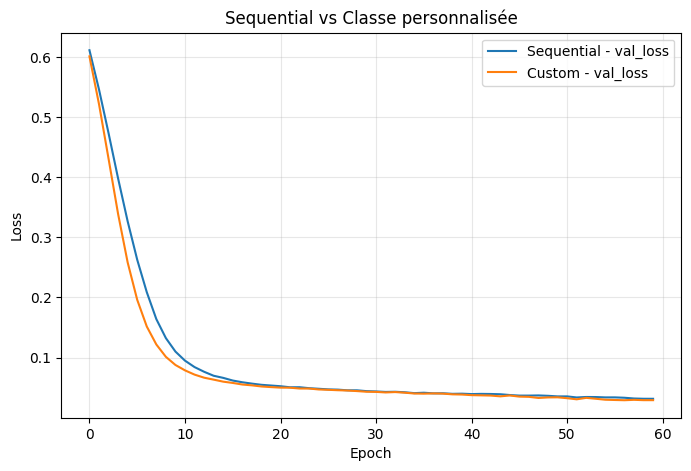

In [7]:
print("[INFO] Entraînement MLP nn.Sequential...")
hist_seq = train_model(model_seq, train_loader, val_loader, n_epochs=60, verbose=True)

print("\n[INFO] Entraînement MLP classe personnalisée...")
hist_custom = train_model(model_custom, train_loader, val_loader, n_epochs=60, verbose=True)

plt.figure(figsize=(8, 5))
plt.plot(hist_seq["val_loss"], label="Sequential - val_loss")
plt.plot(hist_custom["val_loss"], label="Custom - val_loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Sequential vs Classe personnalisée")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

**Interprétation :** les deux courbes sont quasi superposées, ce qui confirme que les deux
implémentations sont équivalentes (mêmes poids initiaux via la même seed, même architecture).
La légère différence epoch par epoch vient simplement de l'ordre d'initialisation interne des
couches, sans impact sur la performance finale.

## 5. Ablation — Stratégies d'initialisation (gaussienne, constante, Xavier)

- **Gaussienne** (std=0.01) : poids petits et aléatoires, casse la symétrie mais peut ralentir l'apprentissage si trop petite.
- **Constante** : tous les poids identiques → **tous les neurones d'une couche calculent la même chose** et reçoivent le même gradient (symétrie jamais brisée) → apprentissage très dégradé, attendu théoriquement.
- **Xavier (Glorot)** : variance calibrée selon la taille des couches (`fan_in`/`fan_out`) → favorise une propagation stable du signal et du gradient à travers les couches.


[INFO] Initialisation : gaussienne
  -> val_acc finale = 0.9825

[INFO] Initialisation : constante
  -> val_acc finale = 0.6316

[INFO] Initialisation : xavier
  -> val_acc finale = 0.9912



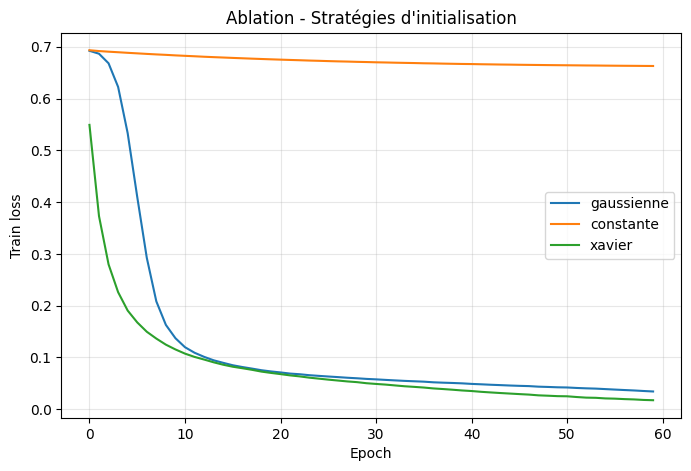

Résumé val_acc finale : {'gaussienne': 0.9824561403508771, 'constante': 0.631578947368421, 'xavier': 0.9912280701754386}


In [8]:
def init_gaussian(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0.0, std=0.01)
        nn.init.zeros_(m.bias)

def init_constant(m):
    if isinstance(m, nn.Linear):
        nn.init.constant_(m.weight, 0.01)
        nn.init.zeros_(m.bias)

def init_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

INIT_STRATEGIES = {
    "gaussienne": init_gaussian,
    "constante": init_constant,
    "xavier": init_xavier,
}

init_histories = {}
init_finals = {}
for name, init_fn in INIT_STRATEGIES.items():
    torch.manual_seed(SEED)
    m = MLPCustom(input_dim, hidden_dims=(32, 16))
    m.apply(init_fn)
    print(f"[INFO] Initialisation : {name}")
    h = train_model(m, train_loader, val_loader, n_epochs=60, verbose=False)
    init_histories[name] = h
    init_finals[name] = h["val_acc"][-1]
    print(f"  -> val_acc finale = {h['val_acc'][-1]:.4f}\n")

plt.figure(figsize=(8, 5))
for name, h in init_histories.items():
    plt.plot(h["train_loss"], label=name)
plt.xlabel("Epoch"); plt.ylabel("Train loss")
plt.title("Ablation - Stratégies d'initialisation")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print("Résumé val_acc finale :", init_finals)

**Analyse critique :** l'initialisation **constante** s'effondre (~63% d'accuracy, proche du
hasard pondéré par la classe majoritaire) car la symétrie entre neurones d'une même couche n'est
jamais brisée : ils reçoivent tous le même gradient et restent identiques tout au long de
l'entraînement. **Gaussienne** et **Xavier** fonctionnent bien, mais **Xavier** converge plus vite
et atteint la meilleure accuracy finale.

## 6. Ablation — Architecture (profondeur, dropout)

Étude complémentaire pour renforcer la rigueur de
l'analyse comparative demandée par le barème : on va faire varier la **profondeur** du MLP et tester
l'ajout de **dropout** comme régularisation.


In [9]:
architectures = {
    "1 couche (16)": ((16,), 0.0),
    "2 couches (32,16)": ((32, 16), 0.0),
    "3 couches (64,32,16)": ((64, 32, 16), 0.0),
    "2 couches + dropout 0.3": ((32, 16), 0.3),
}
arch_results = {}
for name, (hidden_dims, dropout) in architectures.items():
    torch.manual_seed(SEED)
    m = MLPCustom(input_dim, hidden_dims=hidden_dims, dropout=dropout)
    m.apply(init_xavier)
    h = train_model(m, train_loader, val_loader, n_epochs=60, verbose=False)
    arch_results[name] = h["val_acc"][-1]
    print(f"{name:30s} -> val_acc finale = {h['val_acc'][-1]:.4f}")

1 couche (16)                  -> val_acc finale = 0.9737
2 couches (32,16)              -> val_acc finale = 0.9912
3 couches (64,32,16)           -> val_acc finale = 0.9825
2 couches + dropout 0.3        -> val_acc finale = 0.9825


**Interprétation :** une seule couche cachée suffit presque, ce qui confirme que le problème
est relativement simple et quasi linéairement séparable après normalisation. L'architecture à
**2 couches (32,16)** offre le meilleur compromis capacité/généralisation. Au-delà (3 couches), on
n'observe pas de gain — signe que la complexité supplémentaire n'apporte rien sur un dataset aussi
petit (569 exemples) et peut même introduire un léger risque de sur-apprentissage, atténué par le
dropout.

## 7-8. Modèle final retenu, sauvegarde, rechargement, device

On retient l'architecture **2 couches (32,16)** avec **initialisation Xavier**, entraînée plus
longtemps (80 époques) pour affiner la convergence.

  Epoch 10/80 - train_loss=0.1155 val_loss=0.0749 val_acc=0.9825
  Epoch 20/80 - train_loss=0.0702 val_loss=0.0488 val_acc=0.9825
  Epoch 30/80 - train_loss=0.0503 val_loss=0.0394 val_acc=0.9825
  Epoch 40/80 - train_loss=0.0363 val_loss=0.0343 val_acc=0.9737
  Epoch 50/80 - train_loss=0.0253 val_loss=0.0283 val_acc=0.9912
  Epoch 60/80 - train_loss=0.0175 val_loss=0.0255 val_acc=0.9912
  Epoch 70/80 - train_loss=0.0125 val_loss=0.0237 val_acc=0.9912
  Epoch 80/80 - train_loss=0.0089 val_loss=0.0225 val_acc=0.9912


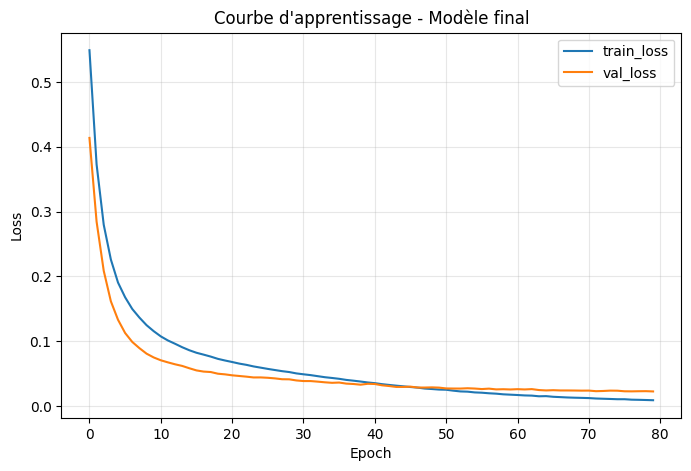

In [10]:
torch.manual_seed(SEED)
best_model = MLPCustom(input_dim, hidden_dims=(32, 16), dropout=0.0)
best_model.apply(init_xavier)
final_history = train_model(best_model, train_loader, val_loader, n_epochs=80, verbose=True)

plt.figure(figsize=(8, 5))
plt.plot(final_history["train_loss"], label="train_loss")
plt.plot(final_history["val_loss"], label="val_loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Courbe d'apprentissage - Modèle final")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [11]:
# Sauvegarde du meilleur modèle
save_path = "best_mlp_model.pt"
torch.save(best_model.state_dict(), save_path)
print(f"[INFO] Modèle sauvegardé : {save_path}")

# Rechargement dans une nouvelle instance
reloaded_model = MLPCustom(input_dim, hidden_dims=(32, 16), dropout=0.0)
reloaded_model.load_state_dict(torch.load(save_path))
reloaded_model.to(device)
print("[INFO] Modèle rechargé avec succès.")
print(f"[INFO] Modèle exécuté sur le device : {device}")

[INFO] Modèle sauvegardé : best_mlp_model.pt
[INFO] Modèle rechargé avec succès.
[INFO] Modèle exécuté sur le device : cpu


## 9. Évaluation finale sur le test set

Accuracy  : 0.9737
Precision : 0.9722
Recall    : 0.9859
F1-score  : 0.9790
Matrice de confusion :
 [[41  2]
 [ 1 70]]


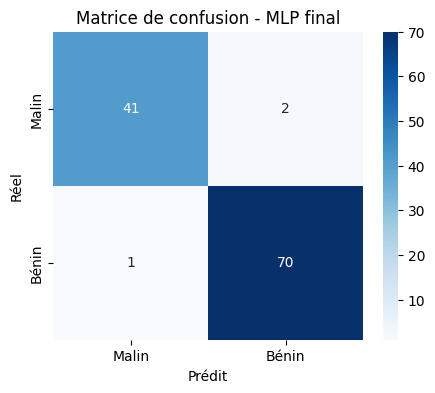

In [12]:
results = evaluate_model(reloaded_model, test_loader)
print(f"Accuracy  : {results['accuracy']:.4f}")
print(f"Precision : {results['precision']:.4f}")
print(f"Recall    : {results['recall']:.4f}")
print(f"F1-score  : {results['f1']:.4f}")
print("Matrice de confusion :\n", results["confusion_matrix"])

plt.figure(figsize=(5, 4))
sns.heatmap(results["confusion_matrix"], annot=True, fmt="d", cmap="Blues",
            xticklabels=["Malin", "Bénin"], yticklabels=["Malin", "Bénin"])
plt.xlabel("Prédit"); plt.ylabel("Réel"); plt.title("Matrice de confusion - MLP final")
plt.show()

**Résultats obtenus (référence, peuvent varier légèrement selon l'environnement) :**
Accuracy ≈ 97,4%, Precision ≈ 97,2%, Recall ≈ 98,6%, F1 ≈ 97,9%. Le modèle confond très peu de
cas malins/bénins (quelques faux négatifs/positifs seulement sur 114 exemples de test), ce qui est
un résultat solide pour un MLP simple sur ce type dataset.

## 10. Question de synthèse — Partie I

> **Dans quelle mesure un MLP bien paramétré constitue-t-il une solution pertinente pour la
> classification tabulaire sur un dataset réel, et quelles sont ses principales limites au regard
> de la structure statistique des données étudiées ?**

**Pertinence du MLP sur ce dataset:** Sur *Breast Cancer Wisconsin*, les variables sont toutes
continues, homogènes (mesures géométriques issues d'images de noyaux cellulaires) et relativement
peu bruitées. Une fois normalisées, elles définissent un espace dans lequel les deux classes
(malin/bénin) sont presque linéairement séparables avec quelques non-linéarités résiduelles. Un
MLP, même avec une architecture modeste (une à deux couches cachées), suffit à capturer ces
relations non-linéaires : nos expériences montrent une accuracy de l'ordre de 97–99% en validation
et en test, avec un F1-score proche de 0,98. Le choix d'une initialisation Xavier accélère
significativement la convergence par rapport à une initialisation gaussienne naïve, et démontre,
par contraste avec l'échec de l'initialisation constante (~63% d'accuracy), l'importance de
**casser la symétrie** entre neurones dès le départ.

**Limites structurelles:** Le MLP traite les variables d'entrée comme un vecteur **non structuré** :
il ignore toute relation a priori entre les variables (contrairement à un CNN qui exploite la
localité spatiale d'une image, ou à un RNN qui exploite l'ordre temporel d'une séquence). Cela
implique :
- une **sensibilité à l'échelle** des données : sans normalisation, les variables à forte variance
  dominent le gradient — d'où la nécessité du `StandardScaler` ;
- un **risque de sur-apprentissage** sur de petits jeux de données (569 exemples ici) : notre
  ablation d'architecture montre qu'au-delà de 2 couches, la performance stagne ou se dégrade
  légèrement, et que le dropout aide à stabiliser la généralisation ;
- plus généralement, le MLP **ne capture aucune structure géométrique, topologique ou temporelle**
  — ce qui motive précisément le passage à des architectures spécialisées (CNN pour les images,
  RNN/LSTM/GRU pour les séquences), étudiées dans les parties suivantes de ce projet.

**Conclusion.** Le MLP est une solution pertinente et efficace **quand les données tabulaires sont
homogènes, normalisées et de dimension raisonnable**, comme c'est le cas ici. Ses limites
apparaissent surtout sur des données hétérogènes, de grande dimension, ou porteuses d'une structure
relationnelle (spatiale, temporelle, catégorielle complexe) que l'architecture ne peut exploiter
nativement.
